In [ ]:
# Import required libraries for data handling, visualization,
# regression modeling, clustering, and preprocessingimport numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the house dataset into a pandas DataFrame
# This dataset contains features like area, bedrooms, etc., and target price
df = pd.read_csv("house_data.csv")

print(df.head())
print(df.columns)

X_cluster = df[["area", "bedrooms", "bathrooms", "location_score"]]

   area  bedrooms  bathrooms  floors  age  location_score     price
0  1660         4          4       3   11               6  10960000
1  2094         3          1       2    0               5  10482000
2  1930         3          3       3   21               9  11970000
3  1895         1          4       2   11              10  11565000
4  2438         5          3       1    4               8  14034000
Index(['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'location_score',
       'price'],
      dtype='str')


In [17]:
X = df.drop("price", axis=1)
y = df["price"]

print(df)

     area  bedrooms  bathrooms  floors  age  location_score     price
0    1660         4          4       3   11               6  10960000
1    2094         3          1       2    0               5  10482000
2    1930         3          3       3   21               9  11970000
3    1895         1          4       2   11              10  11565000
4    2438         5          3       1    4               8  14034000
..    ...       ...        ...     ...  ...             ...       ...
195  2507         2          3       2    7               9  13281000
196  2495         1          1       2    7               8  11745000
197  2533         5          1       3   16               7  13479000
198  2239         5          2       3   11              10  14197000
199  3094         1          2       2   18               6  12822000

[200 rows x 7 columns]


In [ ]:
#test train split for model train and test the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

error = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", error)

Mean Absolute Error: 1.6600824892520904e-08


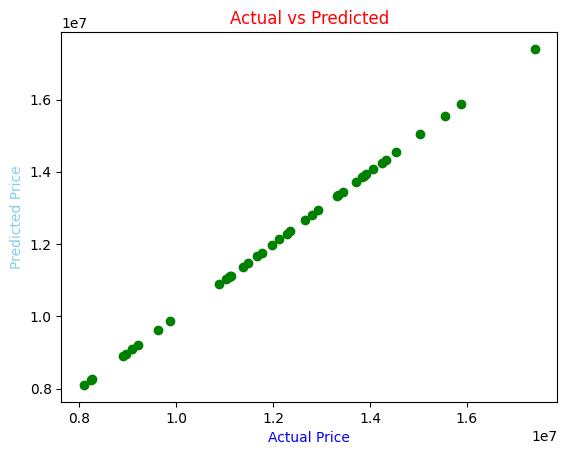

In [ ]:
#Graphcal representaion of the data on scatter plot
plt.scatter(y_test, predictions,color = 'green')
plt.xlabel("Actual Price",color = 'blue')
plt.ylabel("Predicted Price",color= 'skyblue')
plt.title("Actual vs Predicted",color='red')
plt.show()

In [ ]:
#pridict price with custom input
new_house = [[1500, 3, 2, 1, 5, 7]]

predicted_price = model.predict(new_house)
print("Predicted Price:", predicted_price[0])

Predicted Price: 9500000.000000024


d:\pyhton\all case studies\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
print("Model Coefficients:", model.coef_)

Model Coefficients: [  3000. 500000. 300000. 200000. -20000. 400000.]


In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
# Apply KMeans algorithm to group houses into 3 clusters
# Each cluster represents a category of houses
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Category"] = df["Cluster"].map({
    0: "Budget",
    1: "Mid-range",
    2: "Premium"
}) 

print(df.head())


   area  bedrooms  bathrooms  floors  age  location_score     price  Cluster  \
0  1660         4          4       3   11               6  10960000        0   
1  2094         3          1       2    0               5  10482000        0   
2  1930         3          3       3   21               9  11970000        2   
3  1895         1          4       2   11              10  11565000        2   
4  2438         5          3       1    4               8  14034000        2   

  Category  
0   Budget  
1   Budget  
2  Premium  
3  Premium  
4  Premium  


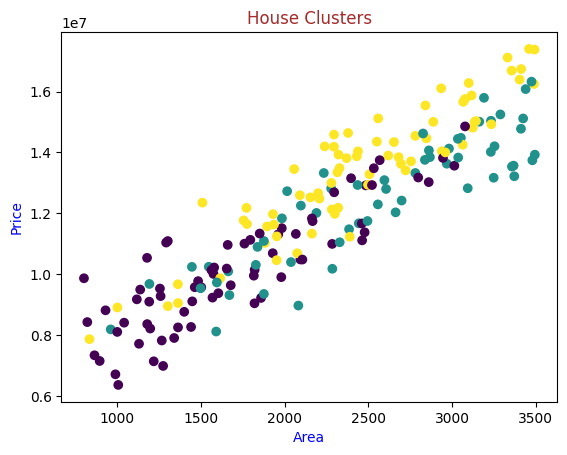

In [ ]:
#cluster graph represntation 

plt.scatter(df["area"], df["price"], c=df["Cluster"])
plt.xlabel("Area",color='blue')
plt.ylabel("Price",color='blue')
plt.title("House Clusters",color='brown')
plt.show()

In [55]:
print(df.groupby("Cluster")[["area", "bedrooms", "bathrooms", "price"]].mean())

                area  bedrooms  bathrooms         price
Cluster                                                
0        1714.585714  3.485714   2.414286  1.015719e+07
1        2555.508475  2.220339   1.355932  1.251534e+07
2        2453.661972  2.887324   3.408451  1.343901e+07


In [56]:
print(df["Category"].value_counts())

Category
Premium      71
Budget       70
Mid-range    59
Name: count, dtype: int64


In [53]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
# Predict price for a new house based on input features
new_house = [[1500, 3, 2, 1, 5, 7]]

In [59]:
predicted_price = model.predict(new_house)

d:\pyhton\all case studies\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [60]:
cluster_input = [[1500, 3, 2, 7]]  
cluster_input_scaled = scaler.transform(cluster_input)

predicted_cluster = kmeans.predict(cluster_input_scaled)

d:\pyhton\all case studies\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Predict which category the new house belongs to using clustering
category_map = {
    0: "Budget",
    1: "Mid-range",
    2: "Premium"
}

category = category_map[predicted_cluster[0]]

In [ ]:
# Display predicted price along with its category
print("Predicted Price:", int(predicted_price[0]))
print("Category:", category)

Predicted Price: 9500000
Category: Budget


In [75]:
# Show average price for each category 
avg_price = df.groupby("Category")["price"].mean()
print(avg_price)

Category
Budget       1.015719e+07
Mid-range    1.251534e+07
Premium      1.343901e+07
Name: price, dtype: float64


In [76]:
avg_price = avg_price.sort_values()
print(avg_price)

Category
Budget       1.015719e+07
Mid-range    1.251534e+07
Premium      1.343901e+07
Name: price, dtype: float64


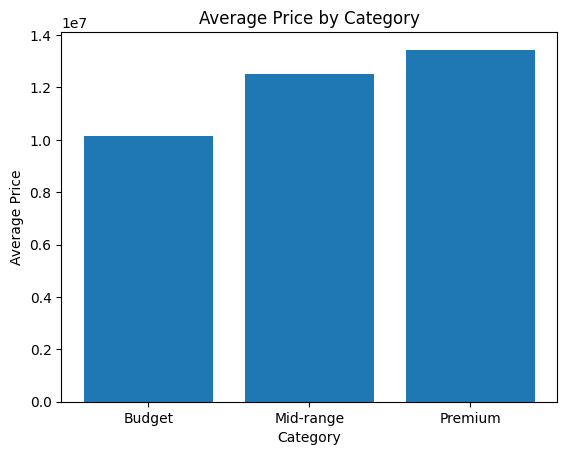

In [ ]:
# Show average price for each category (Budget, Mid-range, Premium)
# Provides business insight
plt.bar(avg_price.index, avg_price.values)
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Average Price by Category")
plt.show()